# Exercises 3

Stochastic differentiation and plain vanilla option pricing

## Exercise 3.1

We are asked to calculate the price of call and put options (European) price using a Geometric Browninan Motion with both continuos and discrete equation. Then compare the result with Black-Scholes equations.

### Geometric Brownian Motion

In the previous notebook we used Random Walks (Brownian Motion) which is an additive process, we are now interested in studying stock prices, which is a multiplicative process. If we consider the current price $S_t$, we expect to find the price at the next timestep to be:
$$
S_{t + \mathrm{d} t} = S_t \cdot W(t)
$$
Where $W(t)$ is a positive random factor, and is depends on time $t$.

After some calculations one finds that:
$$
S_t = S_0 \exp \left[\left( \mu - \frac{\sigma^2}{2} \right)t + \sigma W(t)  \right]
$$
Where $S_0$ is the initial price, $\mu$ is the expected price growth, $\sigma^2$ is the price variance, and $W(t)$ is distributed as a gaussian $W(t) \in \mathcal{N}(0, t)$.

We can apply this formula with $S_t$ as the new start price to obtain the recursive formula:
$$
S_{t_{i+1}} = S_{t_i} \exp\left[ \left(\mu-\frac{1}{2}\sigma^2\right)(t_{i+1}-t_i)
    +\sigma Z_{i+1}\sqrt{t_{i+1}-t_i}\right]
$$
Where $Z_i \in \mathcal{N}(0, 1)$.

We will use both formulas to simulate $10^4$ prices, using $\mu = 0.1$, $\sigma = 0.25$, $S_0 = 100$ and total time $t=1$. For the second formula we divided $t$ in 100 random sub-times, with the constain: $\sum_{i = 1}^{100} t_i = t = 1$.

In [1]:
from cycler import cycler

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

import scienceplots

plt.style.use(["science", "ieee"])

colors = plt.cm.Set2.colors
plt.rcParams["axes.prop_cycle"] = cycler(color=colors)

plt.rcParams["figure.dpi"] = 300

To get the expected value we use the Black-Scholes analytic solution.

In [2]:
def N(x):
    return 0.5 * (1.0 + erf(x / np.sqrt(2.0)))


def black_scholes(S0=100.0, K=100.0, T=1.0, r=0.1, sigma=0.25):
    d1 = 1.0 / (sigma * np.sqrt(T)) * (np.log(S0 / K) + (r + (sigma**2) / 2.0) * T)
    d2 = d1 - sigma * np.sqrt(T)
    C = S0 * N(d1) - K * np.exp(-r * T) * N(d2)
    P = S0 * (N(d1) - 1.0) - K * np.exp(-r * T) * (N(d2) - 1.0)
    return C, P


call, put = black_scholes()

print(f"Theoretical Call Price: {call:.4g}")
print(f"Theoretical Put Price: {put:.4g}")

Theoretical Call Price: 14.98
Theoretical Put Price: 5.46


In [3]:
def plot_black_scholes(
    files: list[str],
    labels: list[str],
    expected: float,
    ylabel: str,
    title: str,
) -> None:
    # plots: the expected value and the simulation data for both continuous and discrete sampling
    plt.figure()

    # expected
    x = np.linspace(0, 100, 10)
    plt.plot(x, expected * np.ones_like(x), label="Expected")

    # data
    for file, label in zip(files, labels):
        data = np.loadtxt(file)
        x_blocks = np.arange(len(data)) + 1

        plt.errorbar(
            x_blocks,
            data[:, 0],
            data[:, 1],
            label=label,
            alpha=0.7,
        )

    plt.xlabel("Block Number")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()

    plt.show()

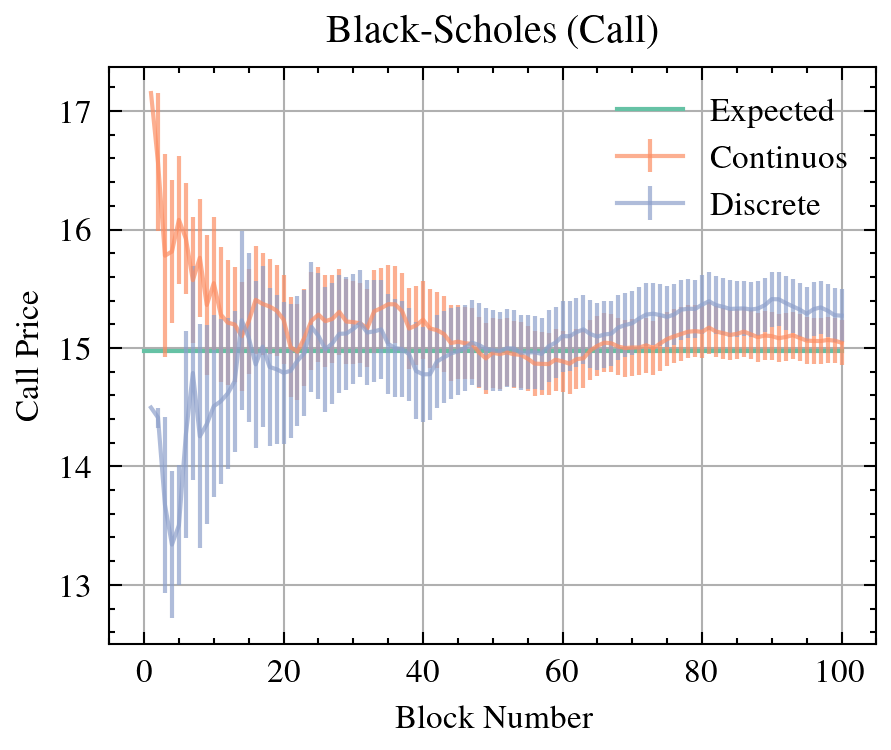

In [4]:
plot_black_scholes(
    files=[
        "./Exer_03_01/call_continuos.dat",
        "./Exer_03_01/call_discrete.dat",
    ],
    labels=["Continuos", "Discrete"],
    expected=call,
    ylabel="Call Price",
    title="Black-Scholes (Call)",
)

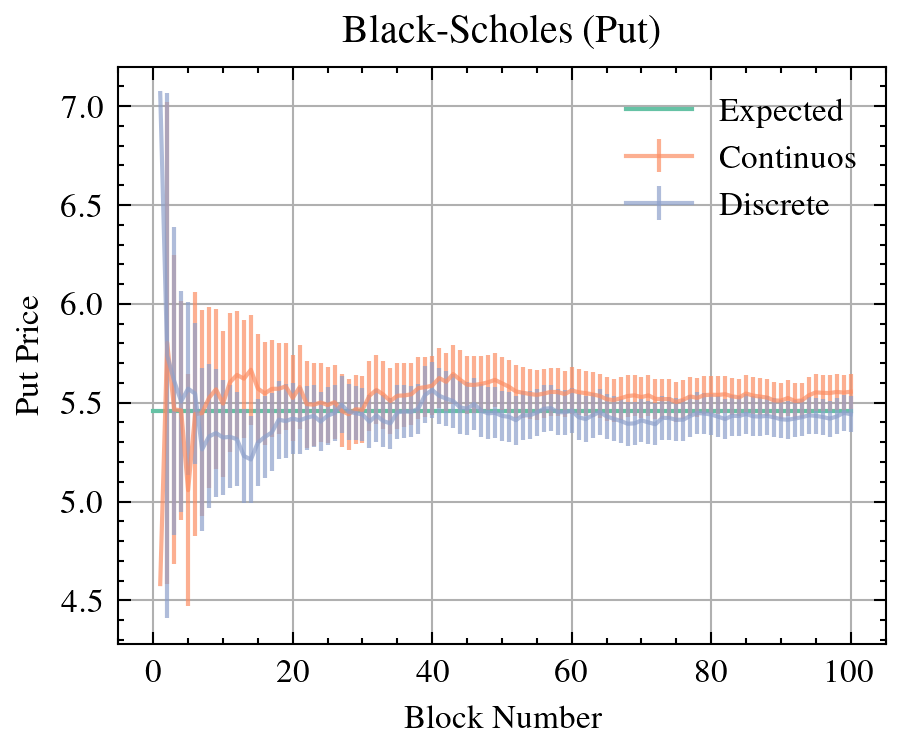

In [5]:
plot_black_scholes(
    files=[
        "./Exer_03_01/put_continuos.dat",
        "./Exer_03_01/put_discrete.dat",
    ],
    labels=["Continuos", "Discrete"],
    expected=put,
    ylabel="Put Price",
    title="Black-Scholes (Put)",
)